# Supermarket Sales Analysis

This project analyzes supermarket sales data to identify patterns in product lines, cities, and customer behavior.

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
conn = sqlite3.connect("sales.db")

df = pd.read_sql_query("SELECT * FROM sales", conn)

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [3]:
product_sales = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

product_sales

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

In [8]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
city_sales

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64

In [9]:
gender_sales = df.groupby("Gender")["Sales"].sum().sort_values(ascending=False)
gender_sales

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

## Key Insights

- Food and Beverages is the top-performing product category.
- Sales distribution varies across cities, with one city leading in total revenue.
- Female customers contribute more to total sales than male customers.

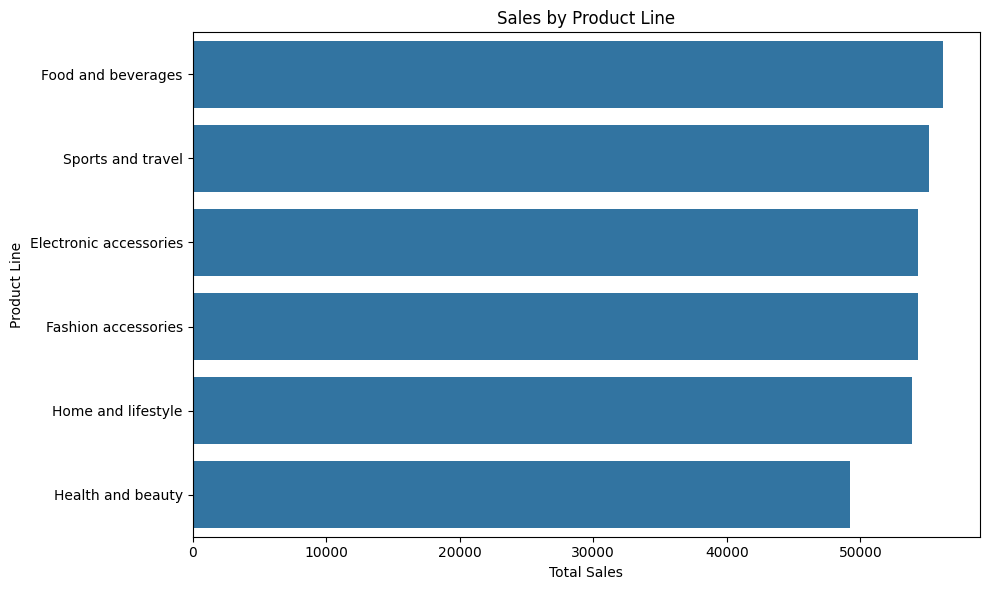

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.tight_layout()

plt.savefig("product_sales.png", dpi=300, bbox_inches="tight")

plt.show()

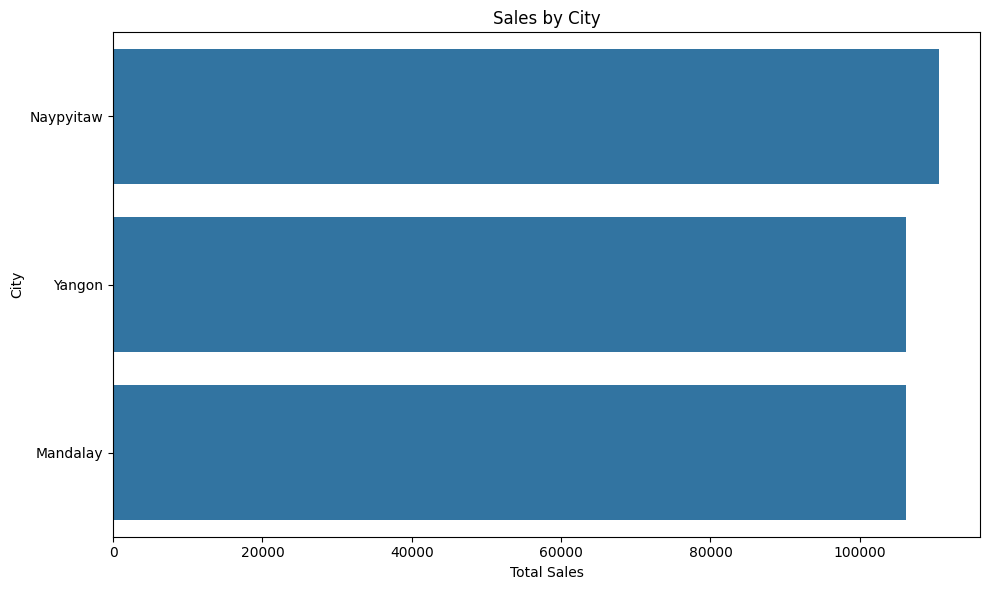

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Sales by City")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.tight_layout()

plt.savefig("city_sales.png", dpi=300, bbox_inches="tight")

plt.show()

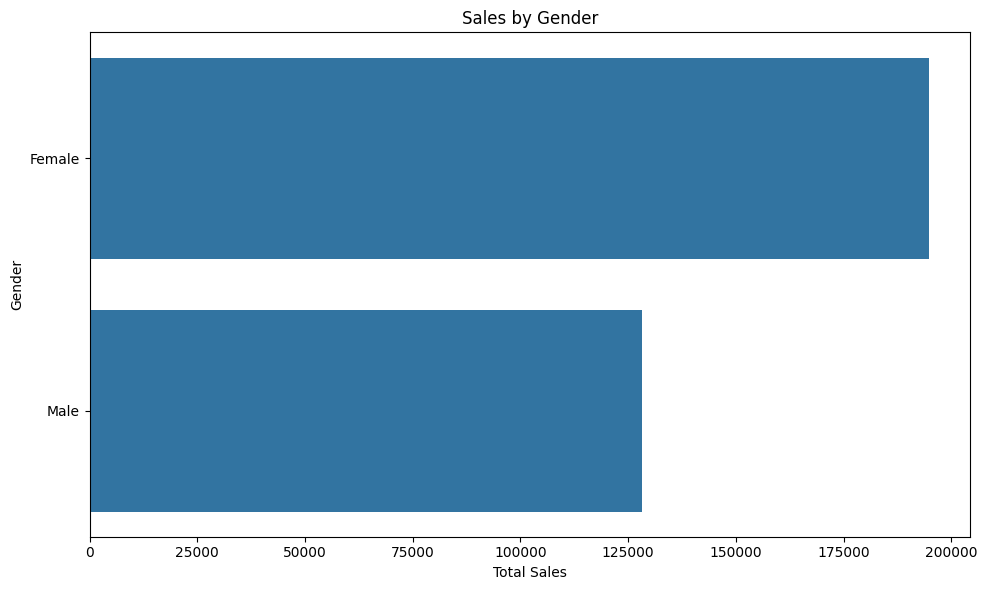

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=gender_sales.values,
    y=gender_sales.index
)

plt.title("Sales by Gender")
plt.xlabel("Total Sales")
plt.ylabel("Gender")

plt.tight_layout()

plt.savefig("gender_sales.png", dpi=300, bbox_inches="tight")

plt.show()